# Calculating Beta in Python

**Wall Street Prep — AI & Python for Finance Professionals**

In this session we'll measure the *systematic risk* of three household-name stocks by calculating their **beta (β)** from historical price data, using `pandas` and `statsmodels` — and then dig into *why* their betas are so different.

### Agenda (~25 minutes)

| # | Section | Time |
|---|---------|------|
| 1 | What is beta? A 3-minute refresher | 3 min |
| 2 | Pulling historical OHLC price data | 4 min |
| 3 | Computing log returns | 4 min |
| 4 | Visualizing stock vs. market returns | 3 min |
| 5 | Running the OLS regressions | 5 min |
| 6 | Interpreting the output: why the betas differ | 6 min |
| 7 | Sanity check + bonus: rolling beta | 3 min |

> **Follow along:** run each cell yourself with `Shift + Enter`. If you fall behind, don't worry — every cell runs independently of the discussion.

## 1. What is beta?

Beta measures how sensitive a stock's returns are to the overall market's returns — its **systematic risk** (the risk you *cannot* diversify away).

It comes straight from the **CAPM**:

$$ E[R_i] = R_f + \beta_i \left( E[R_m] - R_f \right) $$

Statistically, beta is the slope of a linear regression of the stock's returns on the market's returns:

$$ R_{stock} = \alpha + \beta \, R_{market} + \varepsilon $$

which is equivalent to:

$$ \beta = \frac{\mathrm{Cov}(R_{stock},\ R_{market})}{\mathrm{Var}(R_{market})} $$

**Rules of thumb:**

| Beta | Interpretation |
|------|----------------|
| β > 1 | Amplifies market moves (more systematic risk) |
| β ≈ 1 | Moves with the market |
| 0 < β < 1 | Dampens market moves (defensive) |
| β < 0 | Moves against the market (rare) |

### Our examples

Three companies everyone knows, against the **S&P 500** (`^GSPC`):

- **Carnival** (`CCL`) — cruise lines
- **Disney** (`DIS`) — media, parks, streaming
- **Coca-Cola** (`KO`) — beverages

**Sample: 7 years of daily prices (July 2019 – June 2026).** That window is roughly one full economic cycle — late-cycle expansion, the COVID recession, the stimulus-fueled recovery, the 2022 rate-hike bear market, and the expansion since. Measuring beta over a full cycle matters: a window that only covers a bull market can badly misstate how a stock behaves when the economy turns.

> **Quick check:** before we compute anything — rank Carnival, Disney, and Coca-Cola by beta, highest to lowest. What's your reasoning? Keep your ranking in mind; we'll see who's right.

## Setup

All imports live here. If anything fails, run `uv sync` in your terminal first.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Pulling historical OHLC data

We'll use `yfinance` to download daily **OHLC** (Open, High, Low, Close) bars plus volume for each ticker.

Two practical points that matter on the job:

1. **Use adjusted prices.** Splits and dividends create artificial jumps in raw close prices. `auto_adjust=True` gives us a close series adjusted for both, so returns reflect *total* economic performance.
2. **Cache your data.** We save each download to `data/` so the lesson still runs if the Wi-Fi (or Yahoo) has a bad day.

In [2]:
STOCK_TICKERS = ["CCL", "DIS", "KO"]
MARKET_TICKER = "^GSPC"
START_DATE = "2019-07-01"
END_DATE = "2026-06-30"
DATA_DIR = "data"


def load_prices(ticker: str, start: str, end: str) -> pd.DataFrame:
    """Download daily OHLCV bars, falling back to a local CSV cache if offline."""
    cache_path = os.path.join(DATA_DIR, f"{ticker.lstrip('^')}.csv")
    try:
        df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        if df.empty:
            raise ValueError(f"No data returned for {ticker}")
        os.makedirs(DATA_DIR, exist_ok=True)
        df.to_csv(cache_path)
    except Exception as exc:
        print(f"Download failed ({exc}); loading cached file {cache_path}")
        df = pd.read_csv(cache_path, index_col=0, parse_dates=True)
    return df


market_prices = load_prices(MARKET_TICKER, START_DATE, END_DATE)
stock_prices = {ticker: load_prices(ticker, START_DATE, END_DATE) for ticker in STOCK_TICKERS}

stock_prices["CCL"].head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2019-07-01,44.2629,45.0279,44.1482,44.7124,4821000
2019-07-02,44.4924,44.5211,44.0621,44.3107,4150300
2019-07-03,44.1577,44.6359,44.0143,44.6359,2599300
2019-07-05,44.8558,44.9132,44.3681,44.6263,3597100
2019-07-08,44.3872,44.8653,44.2821,44.6072,4066200


Each row is one trading day. We get the classic OHLC bar — **Open**, **High**, **Low**, **Close** — plus **Volume**. Because we passed `auto_adjust=True`, the Close column is already adjusted for splits and dividends, which is exactly what we want for return calculations.

> **Quick check:** Coca-Cola pays a quarterly dividend. If we used *unadjusted* closes, the price would drop every ex-dividend date even though shareholders lost nothing. Which direction would that bias our return series?

In [3]:
for ticker, prices in {MARKET_TICKER: market_prices, **stock_prices}.items():
    print(f"{ticker:6s} {len(prices):,} rows   ({prices.index.min():%Y-%m-%d} to {prices.index.max():%Y-%m-%d})")

^GSPC  1,758 rows   (2019-07-01 to 2026-06-29)
CCL    1,758 rows   (2019-07-01 to 2026-06-29)
DIS    1,758 rows   (2019-07-01 to 2026-06-29)
KO     1,758 rows   (2019-07-01 to 2026-06-29)


## 3. Computing log returns

Prices aren't comparable across assets — returns are. We'll use **log returns**:

$$ r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right) $$

Why log returns instead of simple percent changes?

- **Time-additive:** the log return over a week is just the *sum* of the daily log returns — handy for aggregating across horizons.
- **Better statistical behavior:** closer to normally distributed, which suits OLS.
- For daily moves the two are nearly identical anyway ($\ln(1+x) \approx x$ for small $x$), so nothing mysterious is happening.

The first row has no prior price, so it becomes `NaN` — we drop it.

In [4]:
def log_returns(prices: pd.DataFrame, column: str = "Close") -> pd.Series:
    """Daily log returns from a price DataFrame."""
    return np.log(prices[column] / prices[column].shift(1)).dropna()


returns = pd.DataFrame(
    {
        "market": log_returns(market_prices),
        **{ticker: log_returns(prices) for ticker, prices in stock_prices.items()},
    }
).dropna()

returns.head()

,market,CCL,DIS,KO
Date,,,,
2019-07-02,0.0029,0.0052,0.0062,0.0073
2019-07-03,0.0076,-0.0076,0.0032,0.0023
2019-07-05,-0.0018,0.0157,0.0025,0.0002
2019-07-08,-0.0048,-0.0105,-0.0101,-0.0021
2019-07-09,0.0012,-0.0108,0.0042,-0.0079


Notice the inner `.dropna()` inside `log_returns` handles the first day, and the outer `.dropna()` on the DataFrame aligns all four series — every row is a date on which *all* of them traded. Regressions need *paired* observations.

In [5]:
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
market,"1,757.0000",0.0005,0.0126,-0.1277,-0.0046,0.0009,0.0067,0.0909
CCL,"1,757.0000",-0.0002,0.0429,-0.4032,-0.0193,-0.0005,0.0188,0.3314
DIS,"1,757.0000",-0.0002,0.0203,-0.1411,-0.0095,-0.0003,0.0094,0.1346
KO,"1,757.0000",0.0004,0.0126,-0.1017,-0.0055,0.0007,0.0064,0.0628


## 4. Visualizing the relationship

Before running any regression, *look at your data*. Each point is one trading day: market return on the x-axis, stock return on the y-axis. Beta is simply the slope of the best-fit line through each cloud.

All three panels share the same axes, so the differences in steepness — and in how tightly the points hug the trend — are directly comparable.

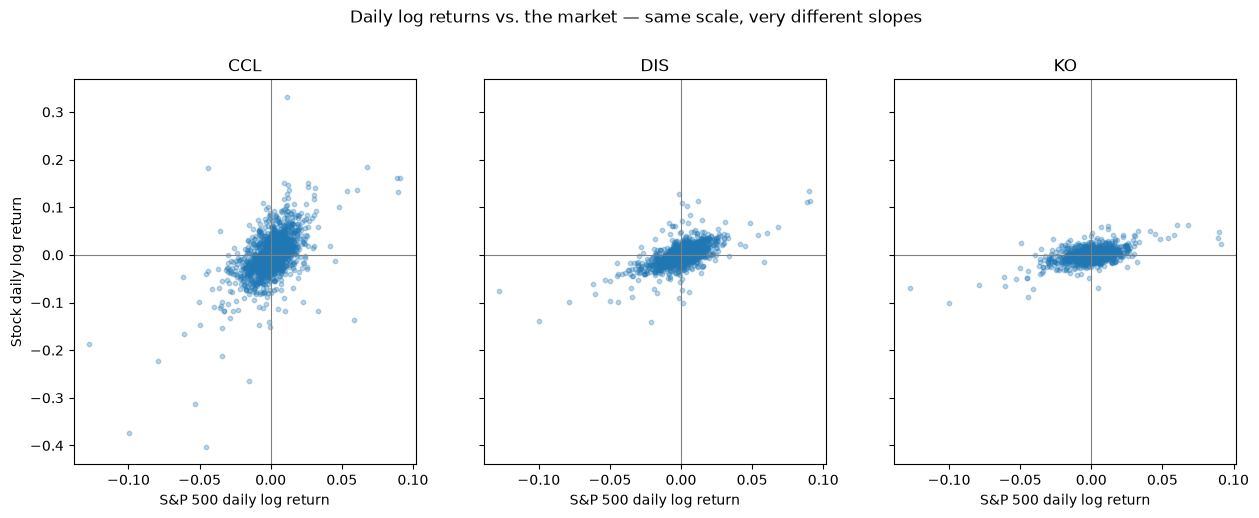

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, ticker in zip(axes, STOCK_TICKERS):
    ax.scatter(returns["market"], returns[ticker], alpha=0.3, s=10)
    ax.axhline(0, color="grey", lw=0.8)
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_title(ticker)
    ax.set_xlabel("S&P 500 daily log return")
axes[0].set_ylabel("Stock daily log return")
fig.suptitle("Daily log returns vs. the market — same scale, very different slopes", y=1.02)
plt.show()

> **Quick check:** without computing anything, which cloud is steepest? Which is flattest but *tightest* around its trend? What does each observation suggest about beta and about R²?

## 5. Running the OLS regressions

For each stock we estimate:

$$ R_{stock} = \alpha + \beta \, R_{market} + \varepsilon $$

with `statsmodels`. Two things to know about the API:

- `sm.OLS(y, X)` takes the **dependent variable first** (the stock), then the regressors (the market).
- `statsmodels` does **not** add an intercept automatically — `sm.add_constant` adds the column of 1s that becomes our alpha.

Let's first run one regression in full detail — Carnival — and read the whole summary table.

In [7]:
X = sm.add_constant(returns["market"])
y = returns["CCL"]

ccl_model = sm.OLS(y, X).fit()
print(ccl_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CCL   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.328
Method:                 Least Squares   F-statistic:                     859.8
Date:                Thu, 16 Jul 2026   Prob (F-statistic):          3.72e-154
Time:                        12:00:07   Log-Likelihood:                 3389.9
No. Observations:                1757   AIC:                            -6776.
Df Residuals:                    1755   BIC:                            -6765.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.001     -1.496      0.1

Now let's wrap that in a small function and run it for all three stocks, collecting the numbers we care about into one comparison table.

In [8]:
def run_beta_regression(stock: pd.Series, market: pd.Series) -> sm.regression.linear_model.RegressionResultsWrapper:
    """OLS of stock returns on market returns (with intercept)."""
    return sm.OLS(stock, sm.add_constant(market)).fit()


def beta_summary(stock: pd.Series, market: pd.Series) -> dict[str, float]:
    """Key regression stats for one stock: beta, CI, alpha, R-squared."""
    model = run_beta_regression(stock, market)
    ci_low, ci_high = model.conf_int().loc["market"]
    return {
        "beta": model.params["market"],
        "ci_low": ci_low,
        "ci_high": ci_high,
        "alpha_annualized": model.params["const"] * 252,
        "r_squared": model.rsquared,
    }


comparison = pd.DataFrame(
    {ticker: beta_summary(returns[ticker], returns["market"]) for ticker in STOCK_TICKERS}
).T

comparison

,beta,ci_low,ci_high,alpha_annualized,r_squared
CCL,1.9458,1.8156,2.0759,-0.3165,0.3288
DIS,1.0261,0.9683,1.0839,-0.1823,0.4088
KO,0.5173,0.4776,0.5570,0.0297,0.2711


And the picture worth a thousand summary tables — all three fitted regression lines on one chart. The slope of each line *is* that stock's beta.

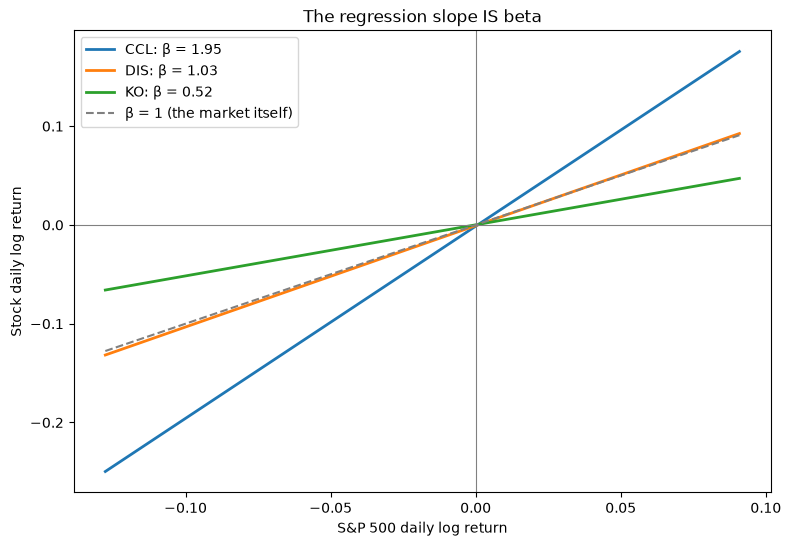

In [9]:
x_line = np.linspace(returns["market"].min(), returns["market"].max(), 100)

fig, ax = plt.subplots(figsize=(9, 6))
for ticker in STOCK_TICKERS:
    stats = comparison.loc[ticker]
    ax.plot(x_line, stats["alpha_annualized"] / 252 + stats["beta"] * x_line,
            lw=2, label=f"{ticker}: β = {stats['beta']:.2f}")
ax.plot(x_line, x_line, color="grey", ls="--", lw=1.5, label="β = 1 (the market itself)")
ax.axhline(0, color="grey", lw=0.8)
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("S&P 500 daily log return")
ax.set_ylabel("Stock daily log return")
ax.set_title("The regression slope IS beta")
ax.legend()
plt.show()

## 6. Interpreting the output: why do the betas differ?

The coefficient on `market` reads as: *for a 1% move in the S&P 500, the stock moves β% on average.* All three companies sell to consumers — yet their betas span roughly 0.5 to 2. The difference isn't the sector label; it's **how sensitive each company's cash flows are to the economy**, amplified or dampened by leverage.

**Carnival (β ≈ 2) — everything that raises beta, at once:**

- *Highly cyclical demand.* A cruise is one of the first purchases households cut in a downturn and one of the last to come back.
- *High operating leverage.* Ships cost billions and sail whether they're full or empty — costs are fixed, so small revenue swings become large profit swings.
- *High financial leverage.* Carnival borrowed heavily to survive 2020; debt magnifies whatever the business does, in both directions.

**Disney (β ≈ 1) — a diversified middle:**

- Parks and advertising are cyclical, but streaming subscriptions and franchise licensing are steadier. The mix nets out to roughly market-like sensitivity.
- Moderate leverage — meaningful debt, but investment-grade and manageable.

**Coca-Cola (β ≈ 0.5) — the classic defensive:**

- *Staple demand.* People don't stop buying soda in a recession; volumes barely notice GDP.
- *Low operating leverage and pricing power.* A franchise bottling model and a brand that can pass through inflation.
- Stable margins and a 60+ year dividend record attract investors who *don't* sell in panics, further dampening the stock's swings.

**The general drivers of beta**, worth memorizing for interviews and comps work:

1. **Cyclicality of demand** — how much revenue moves with GDP
2. **Operating leverage** — fixed vs. variable cost structure
3. **Financial leverage** — debt magnifies equity's exposure to everything above

**Also compare the `r_squared` column — and notice it does *not* rank the same way as beta.** Disney's R² is the highest of the three: its moves are the most market-driven. Carnival has the *biggest* beta but only a moderate R², because on top of its market sensitivity it carries enormous company-specific volatility — booking trends, debt refinancings, health headlines — which the market can't explain. The lesson: **beta measures the slope; R² measures how much of the stock's total variance is systematic.** A stock can be highly market-sensitive and still be dominated by idiosyncratic (diversifiable) risk.

**The `alpha_annualized` column tells its own story.** Carnival's is deeply negative: over this cycle the stock *lost* substantial value beyond what its market exposure predicts. High beta means high systematic risk — it does not mean high realized returns.

**And check the confidence intervals.** Beta is an *estimate*, not a fact — worth remembering when a data vendor quotes beta to two decimals.

### Putting beta to work: CAPM cost of equity

The whole reason bankers care about beta — it drives the cost of equity in a DCF:

$$ E[R] = R_f + \beta \, (E[R_m] - R_f) $$

Watch how the ~1.4 gap in beta between Carnival and Coca-Cola translates into a materially different discount rate — and therefore a materially different valuation.

In [10]:
RISK_FREE_RATE = 0.042
EQUITY_RISK_PREMIUM = 0.05

comparison["cost_of_equity"] = RISK_FREE_RATE + comparison["beta"] * EQUITY_RISK_PREMIUM

for ticker in STOCK_TICKERS:
    row = comparison.loc[ticker]
    print(f"{ticker}: beta = {row['beta']:.2f}  ->  CAPM cost of equity = {row['cost_of_equity']:.2%}")

CCL: beta = 1.95  ->  CAPM cost of equity = 13.93%
DIS: beta = 1.03  ->  CAPM cost of equity = 9.33%
KO: beta = 0.52  ->  CAPM cost of equity = 6.79%


## 7. Sanity check: beta without a regression

Remember the closed-form definition? Let's verify OLS agrees with it:

$$ \beta = \frac{\mathrm{Cov}(R_{stock},\ R_{market})}{\mathrm{Var}(R_{market})} $$

For a single-regressor OLS these are *mathematically identical* — a nice way to demystify what the regression is doing.

In [11]:
for ticker in STOCK_TICKERS:
    beta_formula = returns[ticker].cov(returns["market"]) / returns["market"].var()
    print(f"{ticker}: OLS beta = {comparison.loc[ticker, 'beta']:.6f}   cov/var beta = {beta_formula:.6f}")

CCL: OLS beta = 1.945793   cov/var beta = 1.945793
DIS: OLS beta = 1.026101   cov/var beta = 1.026101
KO: OLS beta = 0.517311   cov/var beta = 0.517311


### Bonus: beta is not a constant

Data vendors quote a single beta, but it drifts as the business and the market regime change. A 1-year rolling window makes that visible — watch what COVID did to Carnival's beta, while Coca-Cola barely moved. This is also why Bloomberg's beta won't match Yahoo's: different windows, frequencies, and indices.

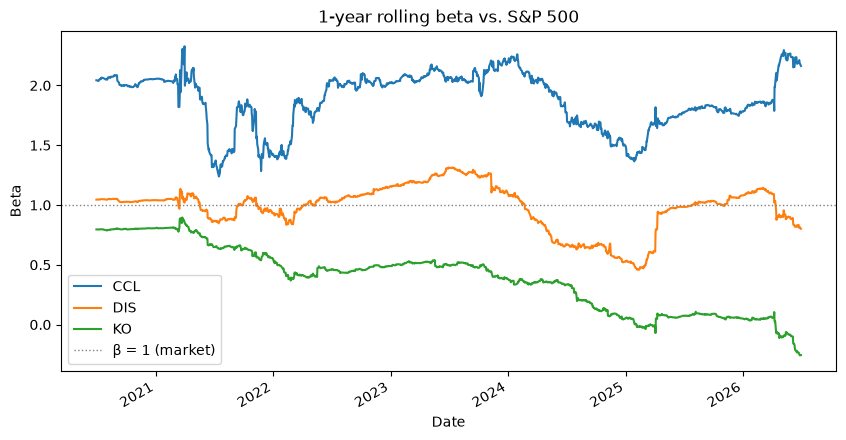

In [12]:
WINDOW = 252

fig, ax = plt.subplots(figsize=(10, 5))
for ticker in STOCK_TICKERS:
    rolling_beta = (
        returns[ticker].rolling(WINDOW).cov(returns["market"])
        / returns["market"].rolling(WINDOW).var()
    )
    rolling_beta.plot(ax=ax, lw=1.5, label=ticker)
ax.axhline(1.0, color="grey", ls=":", lw=1, label="β = 1 (market)")
ax.set_title("1-year rolling beta vs. S&P 500")
ax.set_ylabel("Beta")
ax.legend()
plt.show()

## Wrap-up

**What we did:**

1. Pulled adjusted OHLC data with `yfinance` for three household names (and cached it locally)
2. Converted prices to **log returns** and aligned all the series
3. Ran OLS regressions with `statsmodels` — the slope on the market return **is beta**
4. Explained *why* the betas differ: demand cyclicality, operating leverage, and financial leverage
5. Fed the betas into CAPM cost of equity, verified against the cov/var formula, and watched beta drift over time

**Try it yourself (5-minute exercises):**

- Add a fourth name to `STOCK_TICKERS` — try an airline (`UAL`), a bank (`JPM`), or a utility (`DUK`). Where does it land, and why?
- Re-run with **weekly** returns (`prices["Close"].resample("W-FRI").last()`). How much do the betas change?
- Shorten `START_DATE` to exclude COVID. Whose beta changes the most, and what does that tell you about event-driven windows?

**Discussion questions:**

- Your DCF needs a beta for a private company. No price history exists — what do you do? *(Hint: comparable companies, unlevering/relevering.)*
- Daily data over 7 years vs. monthly data over 5 years: what's the trade-off?
- If Carnival paid down most of its debt, what would you expect to happen to its beta — and which of the three drivers would that change?